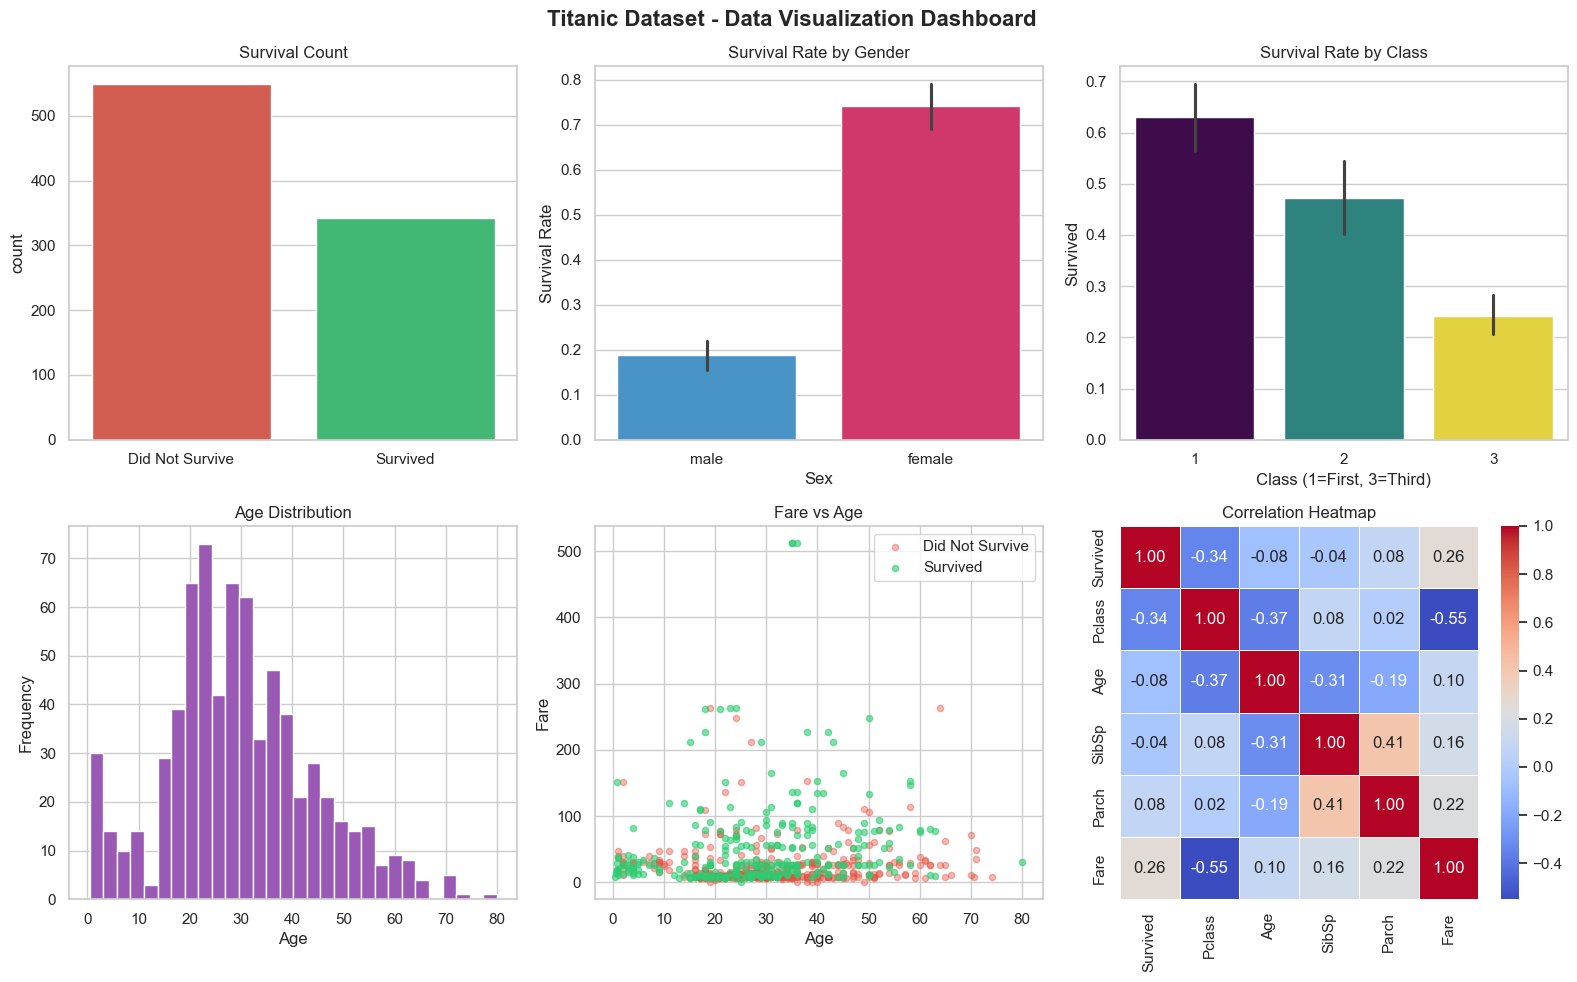

✅ Dashboard saved!


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Titanic Dataset - Data Visualization Dashboard",
             fontsize=16, fontweight="bold")

# 1. Survival Count
sns.countplot(x="Survived", data=df,
              hue="Survived",
              palette=["#e74c3c", "#2ecc71"],
              ax=axes[0, 0], legend=False)
axes[0, 0].set_title("Survival Count")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["Did Not Survive", "Survived"])
axes[0, 0].set_xlabel("")

# 2. Survival by Gender
sns.barplot(x="Sex", y="Survived", data=df,
            hue="Sex",
            palette=["#3498db", "#e91e63"],
            ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Survival Rate by Gender")
axes[0, 1].set_ylabel("Survival Rate")

# 3. Survival by Class
sns.barplot(x="Pclass", y="Survived", data=df,
            hue="Pclass",
            palette="viridis",
            ax=axes[0, 2], legend=False)
axes[0, 2].set_title("Survival Rate by Class")
axes[0, 2].set_xlabel("Class (1=First, 3=Third)")

# 4. Age Distribution
df["Age"].dropna().plot(kind="hist", bins=30,
                        color="#9b59b6",
                        edgecolor="white",
                        ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution")
axes[1, 0].set_xlabel("Age")

# 5. Fare vs Age Scatter
survived = df[df["Survived"] == 1]
not_survived = df[df["Survived"] == 0]
axes[1, 1].scatter(not_survived["Age"],
                   not_survived["Fare"],
                   alpha=0.4, color="#e74c3c",
                   label="Did Not Survive", s=20)
axes[1, 1].scatter(survived["Age"],
                   survived["Fare"],
                   alpha=0.6, color="#2ecc71",
                   label="Survived", s=20)
axes[1, 1].set_title("Fare vs Age")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Fare")
axes[1, 1].legend()

# 6. Correlation Heatmap
corr = df[["Survived","Pclass","Age",
           "SibSp","Parch","Fare"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", ax=axes[1, 2],
            linewidths=0.5)
axes[1, 2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("titanic_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved!")